# Analisis Satelit dan Komparasi Presipitasi Hidrometeorologis

Notebook ini dirancang untuk membandingkan dan menganalisis produk curah hujan satelit, dataset reanalisis, data cuaca Open-Meteo, dan observasi stasiun cuaca IoT lokal. Tujuannya adalah untuk mengevaluasi konsistensi, korelasi, kesesuaian temporal, dan potensi bias.

## Fase-fase Analisis:
1. Data Inspection
2. Temporal Standardization
3. Temporal Resolution Check & Aggregation
4. Rainfall Column Detection
5. Data Alignment
6. Correlation Analysis
7. Visualization
8. Hydrometeorological Interpretation
9. Data Quality Audit
10. Recommendations
11. Export Results


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import Markdown, display
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')


## Phase 1 — Data Inspection
Membuka semua dataset, mendeteksi kolom datetime, unixtime, dan curah hujan secara otomatis, serta menghasilkan ringkasan.

In [2]:
# Definisi Path Dataset
base_dir = r"d:/Github/Projek_Rainfall/Analisis_Meteorologi"

file_paths = {
    'GSMaP': os.path.join(base_dir, 'Data_Satelit', 'Rainfall_GSMaP_TimeSeries_UNIX.csv'),
    'IMERG': os.path.join(base_dir, 'Data_Satelit', 'Rainfall_IMERG_TimeSeries_UNIX.csv'),
    'Oya': os.path.join(base_dir, 'Data_Satelit', 'Rainfall_Oya_TimeSeries_UNIX.csv'),
    'ERA5_Land': os.path.join(base_dir, 'Data_Satelit', 'ERA5_Land_Standard_Units_TimeSeries_UTC_WMO.csv'),
    'ERA5_ML': os.path.join(base_dir, 'Data_Satelit', 'ERA5_Hourly_ML_Features_2000_2026.csv'),
    'Open-Meteo': os.path.join(base_dir, 'open_meteo_jerukagung', 'cuaca_jerukagung.csv'),
    'IoT_id05': os.path.join(base_dir, 'clear_data', 'id-05_clear_data_hourly.parquet')
}

# Fungsi deteksi otomatis
def detect_columns(df):
    cols = [c.lower() for c in df.columns]
    
    # Detect Time
    dt_col, unix_col = None, None
    for c in df.columns:
        cl = c.lower()
        if 'unix' in cl and unix_col is None:
            unix_col = c
        elif ('date' in cl or 'time' in cl) and ('unix' not in cl) and dt_col is None:
            dt_col = c
            
    # Detect Rainfall
    rain_keywords = ['rainfall', 'precipitation', 'precip', 'rain', 'rainrate', 'total_precipitation', 'tp', 'hourly_precipitation']
    rain_cols = []
    for c in df.columns:
        cl = c.lower()
        if any(k in cl for k in rain_keywords):
            # Prioritaskan Gauge-Calibrated jika ada
            if 'gc' in cl:
                rain_cols.insert(0, c)
            else:
                rain_cols.append(c)
                
    rain_col = rain_cols[0] if rain_cols else None
    
    return dt_col, unix_col, rain_col

datasets_raw = {}
summary_data = []

for name, path in file_paths.items():
    if not os.path.exists(path):
        print(f"File not found: {path}")
        continue
        
    if path.endswith('.csv'):
        df = pd.read_csv(path)
    elif path.endswith('.parquet'):
        df = pd.read_parquet(path)
        
    dt_col, unix_col, rain_col = detect_columns(df)
    
    # Kalkulasi resolusi
    resolution = "Unknown"
    start_date, end_date = "Unknown", "Unknown"
    if unix_col and not df.empty:
        df = df.sort_values(unix_col)
        diffs = df[unix_col].diff().dropna()
        mode_diff = diffs.mode().iloc[0] if not diffs.empty else 0
        if mode_diff == 3600:
            resolution = "Hourly"
        elif mode_diff == 1800:
            resolution = "30-Minute"
        elif mode_diff == 86400:
            resolution = "Daily"
        else:
            resolution = f"{mode_diff} seconds"
            
    if dt_col and not df.empty:
        start_date = str(df[dt_col].iloc[0])
        end_date = str(df[dt_col].iloc[-1])
        
    summary_data.append({
        'Dataset': name,
        'Records': len(df),
        'Datetime Field': dt_col,
        'Unix Field': unix_col,
        'Rainfall Field': rain_col,
        'Resolution': resolution,
        'Start': start_date,
        'End': end_date
    })
    
    datasets_raw[name] = df

# Generate Markdown Table
md_table = "| Dataset | Records | Datetime Field | Unix Field | Rainfall Field | Resolution | Start | End |\n"
md_table += "|---|---|---|---|---|---|---|---|\n"
for row in summary_data:
    md_table += f"| {row['Dataset']} | {row['Records']:,} | `{row['Datetime Field']}` | `{row['Unix Field']}` | `{row['Rainfall Field']}` | {row['Resolution']} | {row['Start']} | {row['End']} |\n"

display(Markdown("### Data Inspection Summary\n" + md_table))


### Data Inspection Summary
| Dataset | Records | Datetime Field | Unix Field | Rainfall Field | Resolution | Start | End |
|---|---|---|---|---|---|---|---|
| GSMaP | 231,528 | `datetime_utc` | `unixtime` | `hourlyPrecipRateGC` | 3600000.0 seconds | 2000-01-01 00:00:00 | 2026-05-30 23:00:00 |
| IMERG | 463,056 | `datetime_utc` | `unixtime` | `precipitation_mmhr` | 1800000.0 seconds | 2000-01-01 00:00:00 | 2026-05-30 23:30:00 |
| Oya | 390,990 | `datetime_utc` | `unixtime` | `precipitation_mmhr` | 1800000.0 seconds | 2004-01-31 00:30:00 | 2026-05-26 05:00:00 |
| ERA5_Land | 231,528 | `datetime_utc` | `unixtime` | `total_precipitation_hourly_mm` | 3600000.0 seconds | 2000-01-01 00:00:00 | 2026-05-30 23:00:00 |
| ERA5_ML | 231,528 | `datetime_utc` | `unixtime` | `rain_mm` | 3600000.0 seconds | 2000-01-01 00:00:00 | 2026-05-30 23:00:00 |
| Open-Meteo | 231,744 | `datetime` | `unixtime` | `rain_mm` | Hourly | 2000-01-01 00:00:00+07:00 | 2026-06-08 23:00:00+07:00 |
| IoT_id05 | 17,520 | `datetime_local` | `unixtime` | `rainrate` | Hourly | 2025-01-01 00:00:00 | 2026-12-31 23:00:00 |


## Phase 2, 3, & 4 — Temporal Standardization, Resolution Check, and Rainfall Detection
1. Konversi waktu menjadi *Timeline* yang terstandarisasi berbasis `unixtime`.
2. Mengecek resolusi 30-menit, jika ada maka lakukan resample menjadi per-jam menggunakan agregasi **SUM**. (Kewajiban Meteorologi).
3. Mendeteksi dan mengganti nama variabel curah hujan menjadi seragam (contoh: `rain_GSMaP`).

In [3]:
processed_dfs = {}
validation_logs = []

for name, df in datasets_raw.items():
    df_proc = df.copy()
    dt_col, unix_col, rain_col = detect_columns(df_proc)
    
    if not unix_col or not rain_col:
        validation_logs.append(f"- **{name}**: Failed. Missing Unix/Rainfall column.")
        continue
        
    # Standardize time
    df_proc = df_proc.dropna(subset=[unix_col, rain_col])
    # Handle GSMaP scientific notation in unixtime if any
    df_proc[unix_col] = df_proc[unix_col].astype('float64') 
    
    # Check if unixtime is in milliseconds (values > 1e11)
    if df_proc[unix_col].max() > 1e11:
        df_proc[unix_col] = df_proc[unix_col] / 1000.0
    
    # Check Resolution & Resample if needed
    df_proc = df_proc.sort_values(unix_col)
    mode_diff = df_proc[unix_col].diff().mode().iloc[0]
    
    # Cast unixtime to datetime strictly as UTC
    df_proc['standard_time'] = pd.to_datetime(df_proc[unix_col], unit='s', utc=True)
    df_proc = df_proc.set_index('standard_time')
    
    if mode_diff == 1800:
        # 30-Minute to Hourly via SUM
        original_res = "30-Minute"
        df_hourly = df_proc[[rain_col]].resample('1H').sum()
        validation_logs.append(f"- **{name}**: Resampled from {original_res} to Hourly using **SUM**.")
    else:
        df_hourly = df_proc[[rain_col]].resample('1H').mean() # Regular resampling just to align exact tops of hours
        validation_logs.append(f"- **{name}**: Already Hourly (or other). Resampled to exact Hour bounds using MEAN for temporal safety.")
        
    # Rename column
    final_col_name = f"rain_{name}"
    df_hourly = df_hourly.rename(columns={rain_col: final_col_name})
    
    # Re-insert unixtime as an exact int
    df_hourly['unixtime'] = (df_hourly.index.astype('int64') // 10**9)
    
    processed_dfs[name] = df_hourly.dropna()

display(Markdown("### Temporal Standardization Logs\n" + "\n".join(validation_logs)))


### Temporal Standardization Logs
- **GSMaP**: Already Hourly (or other). Resampled to exact Hour bounds using MEAN for temporal safety.
- **IMERG**: Resampled from 30-Minute to Hourly using **SUM**.
- **Oya**: Resampled from 30-Minute to Hourly using **SUM**.
- **ERA5_Land**: Already Hourly (or other). Resampled to exact Hour bounds using MEAN for temporal safety.
- **ERA5_ML**: Already Hourly (or other). Resampled to exact Hour bounds using MEAN for temporal safety.
- **Open-Meteo**: Already Hourly (or other). Resampled to exact Hour bounds using MEAN for temporal safety.
- **IoT_id05**: Already Hourly (or other). Resampled to exact Hour bounds using MEAN for temporal safety.

## Phase 5 — Dataset Alignment
Menggabungkan semua dataset ke dalam satu tabel lebar menggunakan `unixtime` sebagai Master Key. Hanya membiarkan periode tumpang tindih (overlap) di mana pembandingan memungkinkan.

In [4]:
# Merge all datasets on standard_time (Index)
df_merged = None

for name, df in processed_dfs.items():
    if df_merged is None:
        df_merged = df
    else:
        df_merged = df_merged.merge(df.drop(columns=['unixtime']), left_index=True, right_index=True, how='inner')

# Drop NA to keep only the absolute overlapping period
df_merged = df_merged.dropna()

overlap_start = df_merged.index.min()
overlap_end = df_merged.index.max()
overlap_duration = overlap_end - overlap_start

display(Markdown(f"### Overlap Alignment Summary\n"
                 f"- **Overlap Duration**: {overlap_duration}\n"
                 f"- **Overlapping Record Count**: {len(df_merged):,}\n"
                 f"- **Start Overlap**: {overlap_start}\n"
                 f"- **End Overlap**: {overlap_end}"))

df_merged.head()


### Overlap Alignment Summary
- **Overlap Duration**: 510 days 12:00:00
- **Overlapping Record Count**: 12,253
- **Start Overlap**: 2024-12-31 17:00:00+00:00
- **End Overlap**: 2026-05-26 05:00:00+00:00

,rain_GSMaP,unixtime,rain_IMERG,rain_Oya,rain_ERA5_Land,rain_ERA5_ML,rain_Open-Meteo,rain_IoT_id05
standard_time,,,,,,,,
2024-12-31 17:00:00+00:00,0.0,1735664400,0.82,0.471662,0.071689,0.128269,0.1,0.1
2024-12-31 18:00:00+00:00,0.0,1735668000,1.24,0.439263,0.112057,0.161648,0.2,0.2
2024-12-31 19:00:00+00:00,0.0,1735671600,0.40,0.380793,1.495540,1.497269,1.5,1.5
2024-12-31 20:00:00+00:00,0.0,1735675200,0.03,0.000000,1.475662,1.427174,1.4,1.4
2024-12-31 21:00:00+00:00,0.0,1735678800,0.00,0.000000,1.303971,1.181602,1.2,1.2


## Phase 6 — Correlation Analysis
Melakukan perhitungan korelasi statistik: Pearson, Spearman, dan Kendall.

In [5]:
rain_cols_only = [c for c in df_merged.columns if c.startswith('rain_')]

# Pearson
corr_pearson = df_merged[rain_cols_only].corr(method='pearson')

# Spearman
corr_spearman = df_merged[rain_cols_only].corr(method='spearman')

# Kendall
# corr_kendall = df_merged[rain_cols_only].corr(method='kendall') # Bisa memakan waktu lama untuk data besar, di-comment untuk performa

display(Markdown("### Pearson Correlation Matrix"))
display(corr_pearson)


### Pearson Correlation Matrix

,rain_GSMaP,rain_IMERG,rain_Oya,rain_ERA5_Land,rain_ERA5_ML,rain_Open-Meteo,rain_IoT_id05
rain_GSMaP,1.000000,0.409277,0.386452,0.196659,0.177987,0.178311,0.191264
rain_IMERG,0.409277,1.000000,0.512936,0.200492,0.185532,0.186597,0.294170
rain_Oya,0.386452,0.512936,1.000000,0.176736,0.158406,0.160020,0.386103
rain_ERA5_Land,0.196659,0.200492,0.176736,1.000000,0.969154,0.969317,0.202504
rain_ERA5_ML,0.177987,0.185532,0.158406,0.969154,1.000000,0.999349,0.211662
rain_Open-Meteo,0.178311,0.186597,0.160020,0.969317,0.999349,1.000000,0.211929
rain_IoT_id05,0.191264,0.294170,0.386103,0.202504,0.211662,0.211929,1.000000


In [6]:
def calculate_metrics(df, obs_col, sim_cols):
    import numpy as np
    import pandas as pd
    
    results = []
    # Bersihkan NaN
    df_clean = df.dropna(subset=[obs_col] + sim_cols)
    obs = df_clean[obs_col].values
    
    for sim_col in sim_cols:
        sim = df_clean[sim_col].values
        
        # MSE & RMSE
        mse = np.mean((sim - obs)**2)
        rmse = np.sqrt(mse)
        
        # NSE
        denominator_nse = np.sum((obs - np.mean(obs))**2)
        if denominator_nse == 0:
            nse = np.nan
        else:
            nse = 1 - (np.sum((sim - obs)**2) / denominator_nse)
            
        # KGE
        # Mencegah error jika standard deviasi 0
        std_obs = np.std(obs)
        mean_obs = np.mean(obs)
        
        if std_obs == 0 or mean_obs == 0:
            kge = np.nan
        else:
            # np.corrcoef returns a 2x2 matrix
            r = np.corrcoef(obs, sim)[0, 1]
            alpha = np.std(sim) / std_obs
            beta = np.mean(sim) / mean_obs
            kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
            
        results.append({
            'Dataset': sim_col.replace('rain_', ''),
            'MSE': mse,
            'RMSE': rmse,
            'NSE': nse,
            'KGE': kge
        })
        
    return pd.DataFrame(results).set_index('Dataset')

iot_col = 'rain_IoT_id05'
if iot_col in df_merged.columns:
    sim_cols = [c for c in rain_cols_only if c != iot_col]
    metrics_df = calculate_metrics(df_merged, iot_col, sim_cols)
    display(Markdown("### 📊 Metrik Evaluasi: RMSE, MSE, NSE, dan KGE (Referensi: IoT_id05)"))
    display(metrics_df)
else:
    print("Kolom IoT id-05 tidak ditemukan untuk dianalisis.")

### 📊 Metrik Evaluasi: RMSE, MSE, NSE, dan KGE (Referensi: IoT_id05)

,MSE,RMSE,NSE,KGE
Dataset,,,,
GSMaP,5.706977,2.388928,0.020069,-0.081489
IMERG,10.958305,3.310333,-0.881624,-0.201544
Oya,7.376661,2.716001,-0.266629,0.286756
ERA5_Land,6.110878,2.472019,-0.049284,0.050364
ERA5_ML,6.089998,2.467792,-0.045699,0.059319
Open-Meteo,6.091663,2.468130,-0.045985,0.059319


## Phase 7 — Visualization
1. Heatmap Korelasi
2. Bar Chart Korelasi terhadap IoT Station
3. Time Series Comparison
4. Scatter Plots

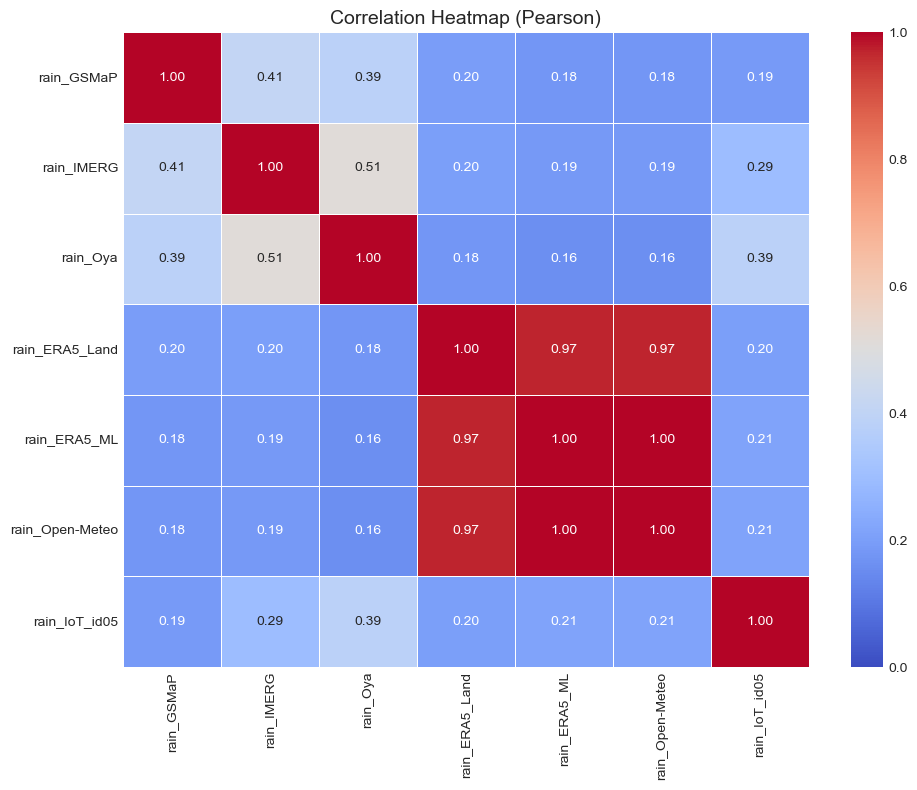

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap (Pearson)', fontsize=14)
plt.tight_layout()
plt.show()


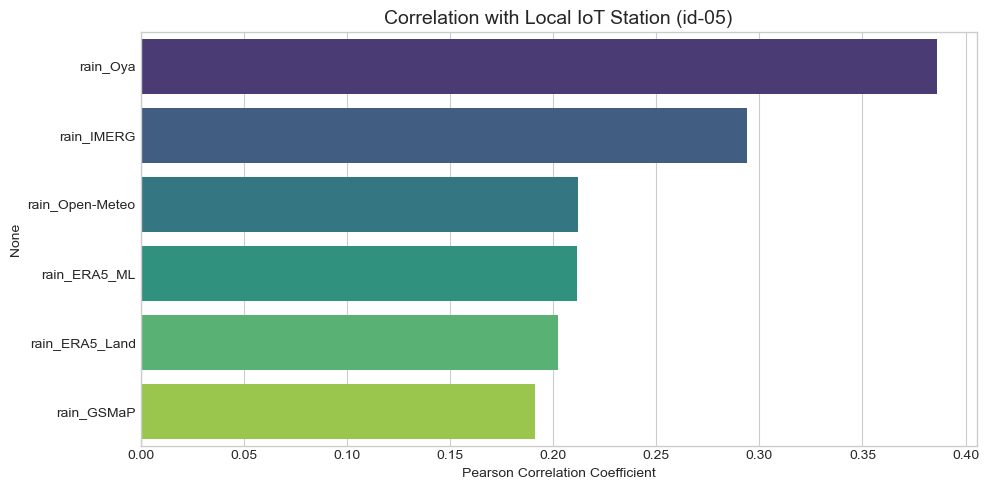

In [8]:
# Bar Chart of Correlations with IoT_id05
iot_col = 'rain_IoT_id05'
if iot_col in corr_pearson.columns:
    corr_with_iot = corr_pearson[iot_col].drop(iot_col).sort_values(ascending=False)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=corr_with_iot.values, y=corr_with_iot.index, palette='viridis')
    plt.title('Correlation with Local IoT Station (id-05)', fontsize=14)
    plt.xlabel('Pearson Correlation Coefficient')
    plt.tight_layout()
    plt.show()


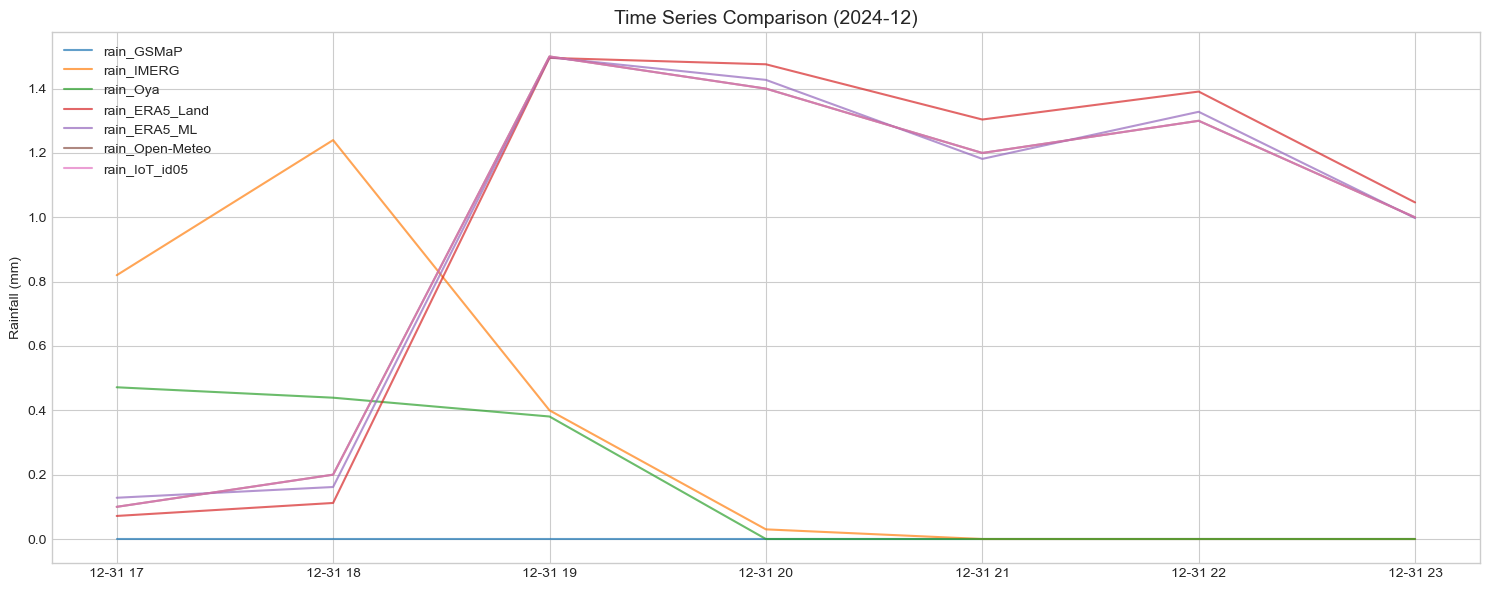

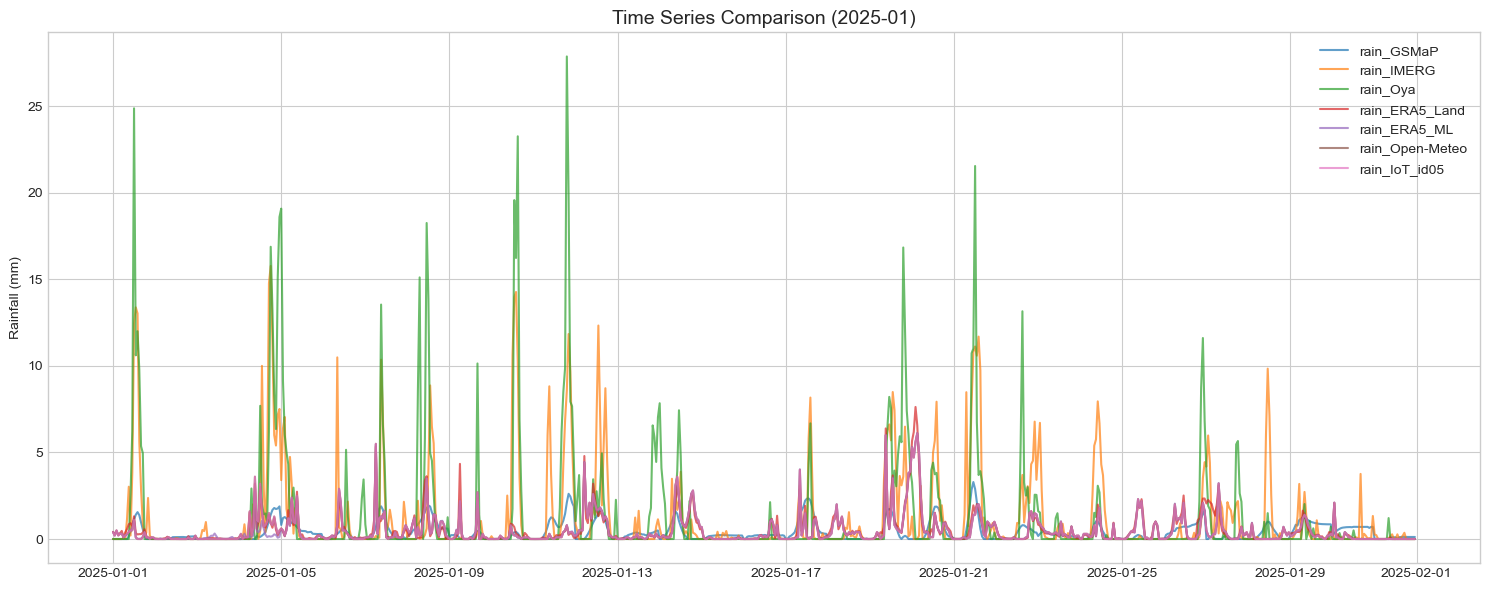

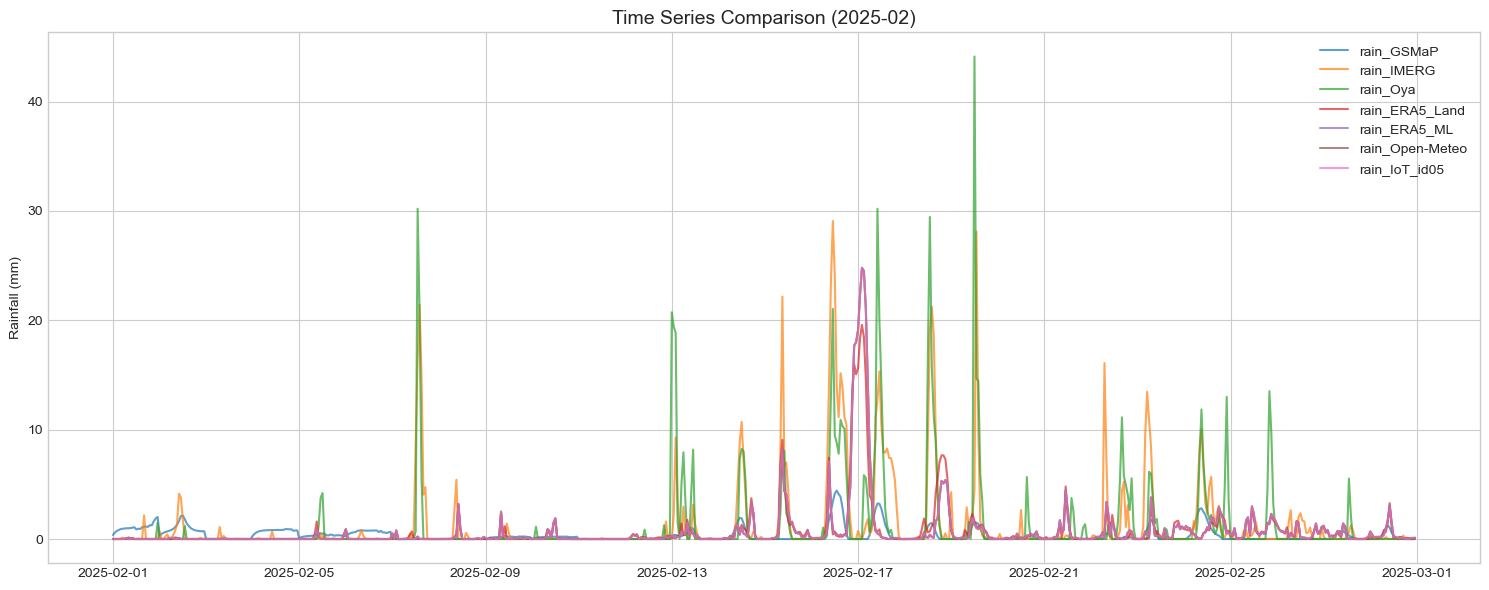

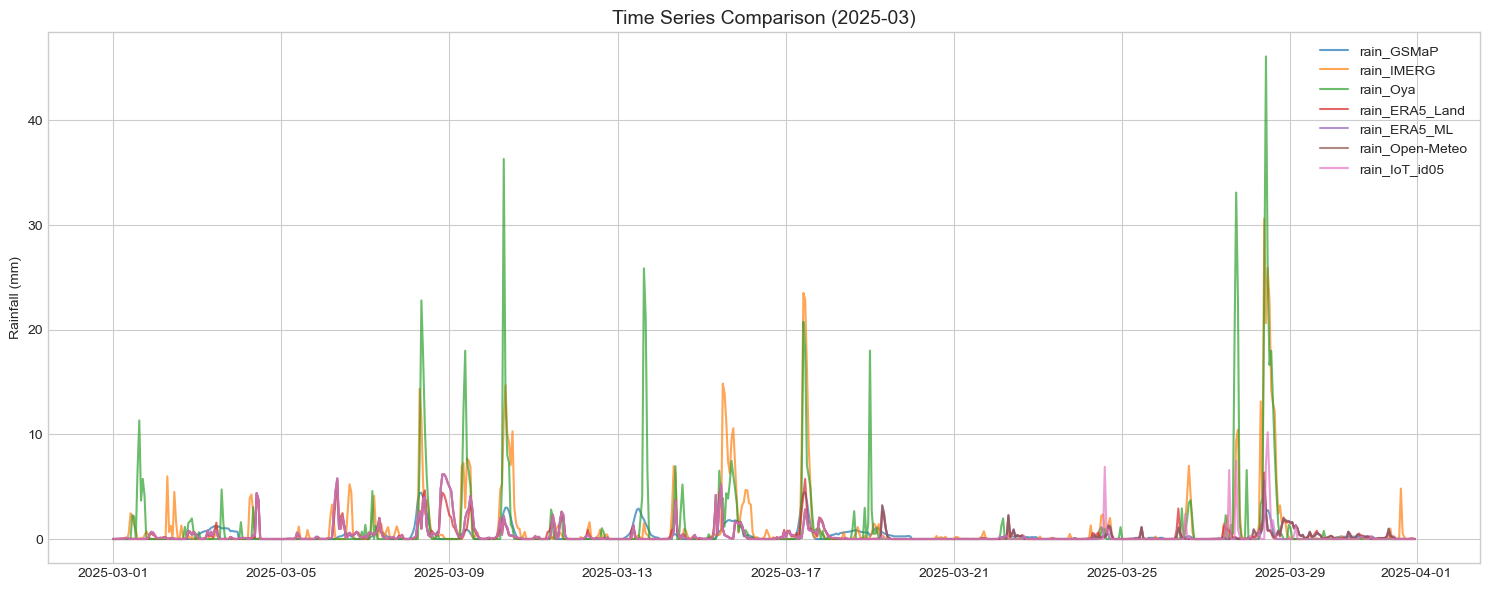

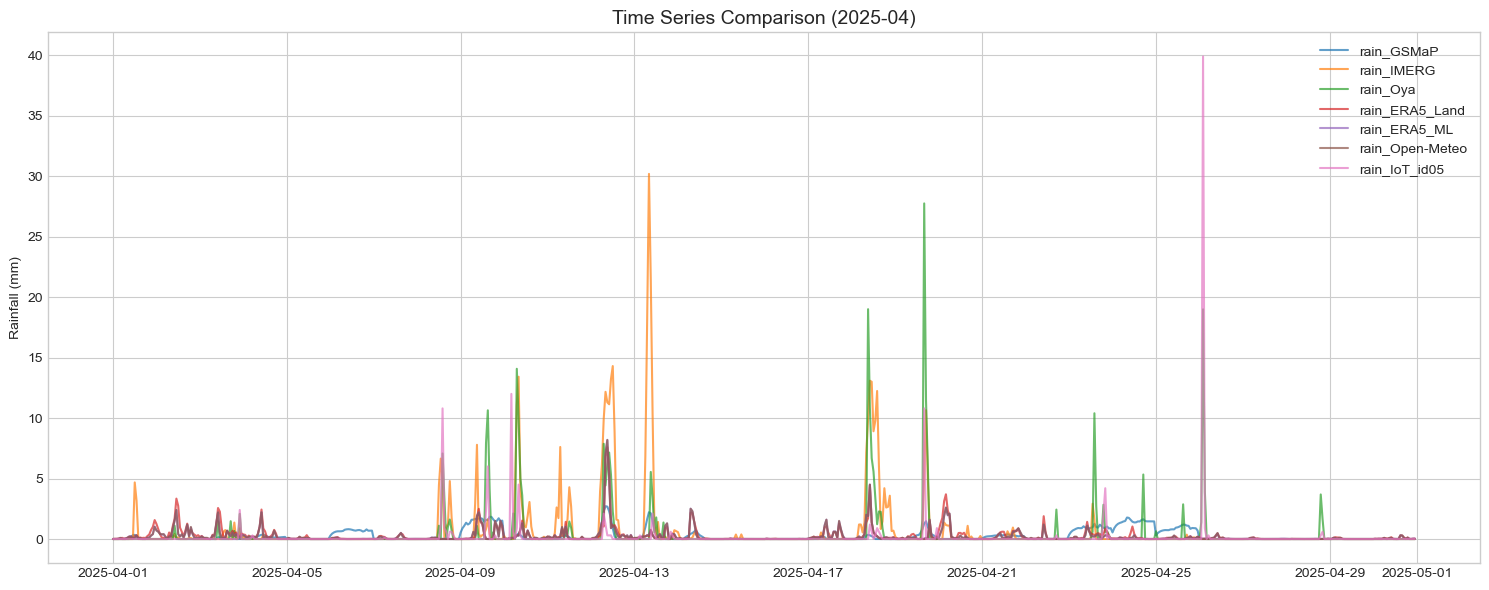

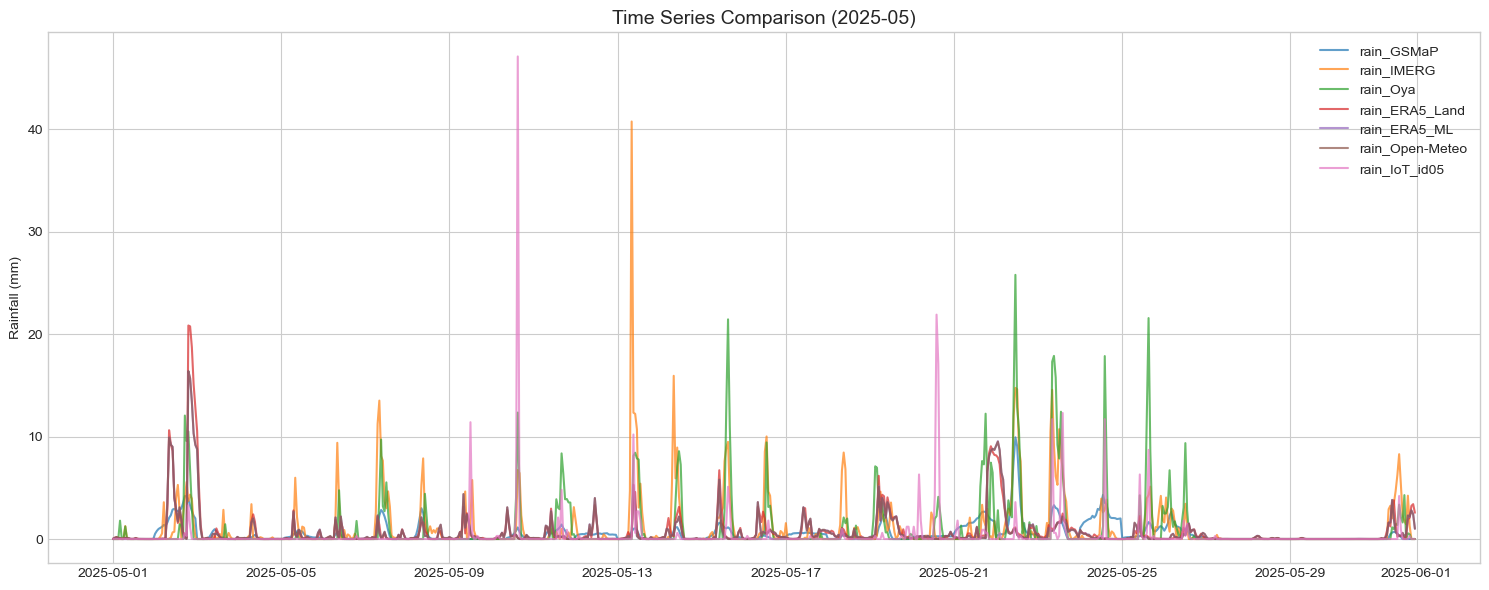

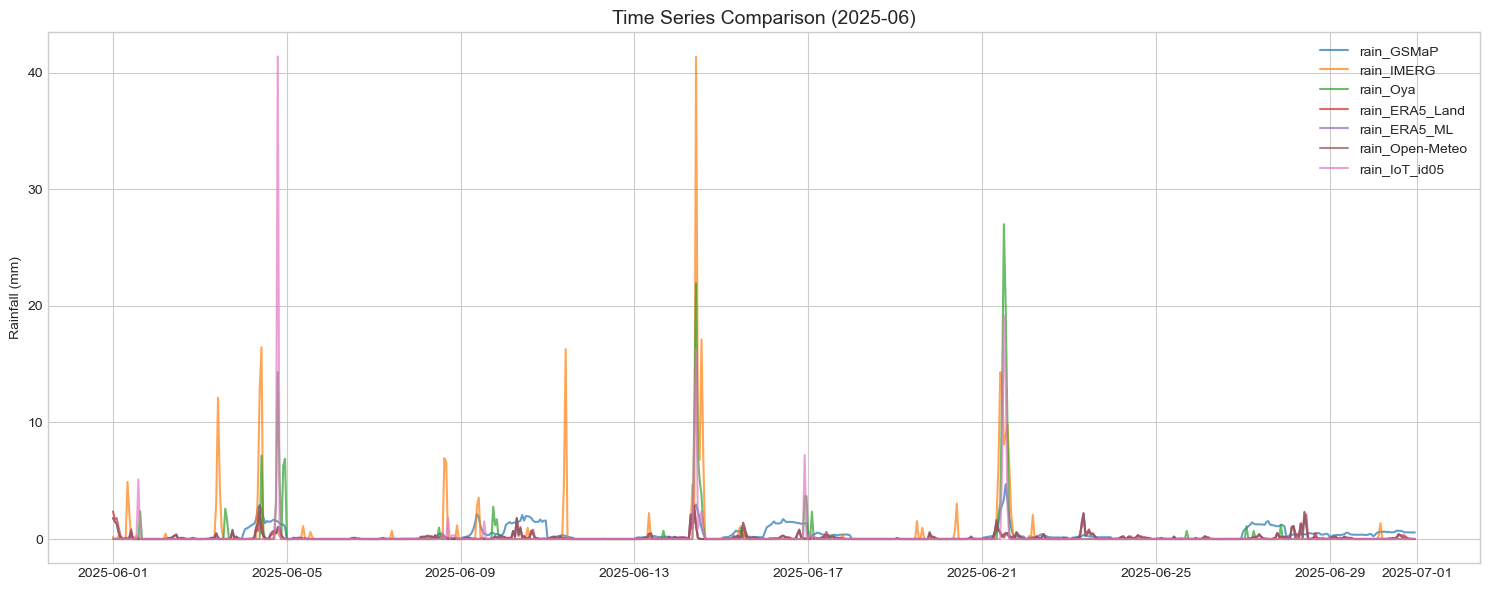

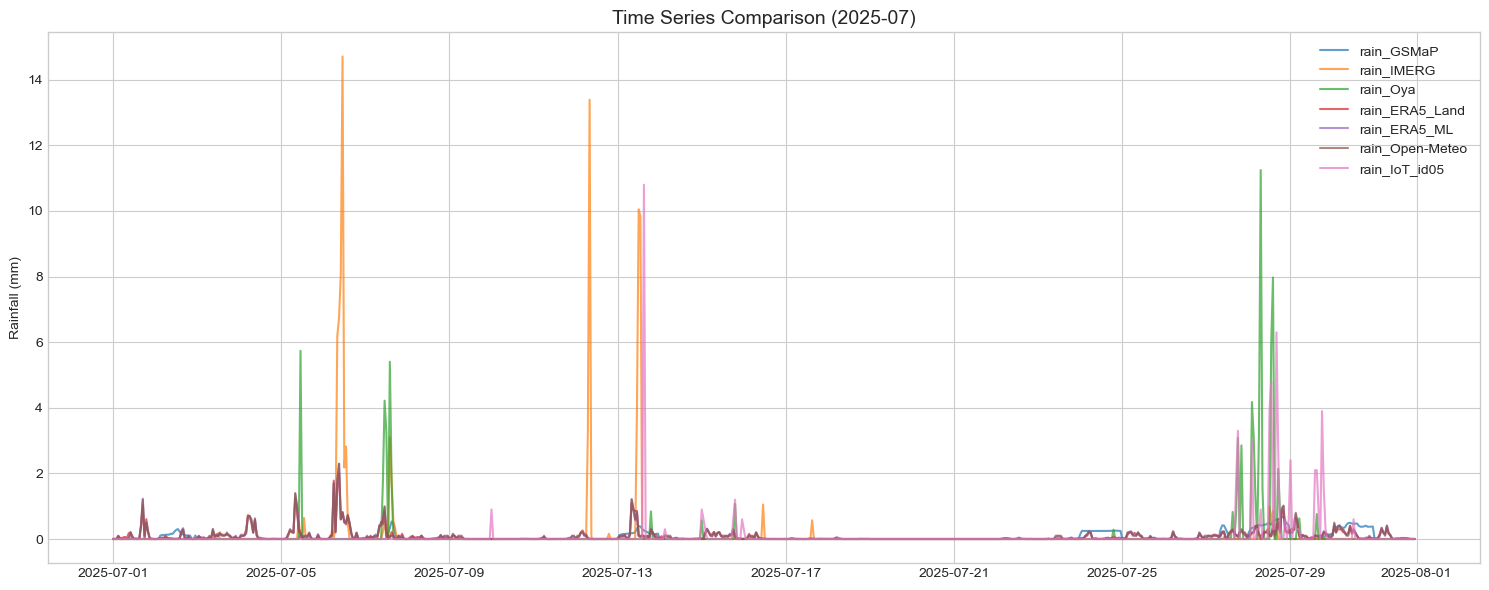

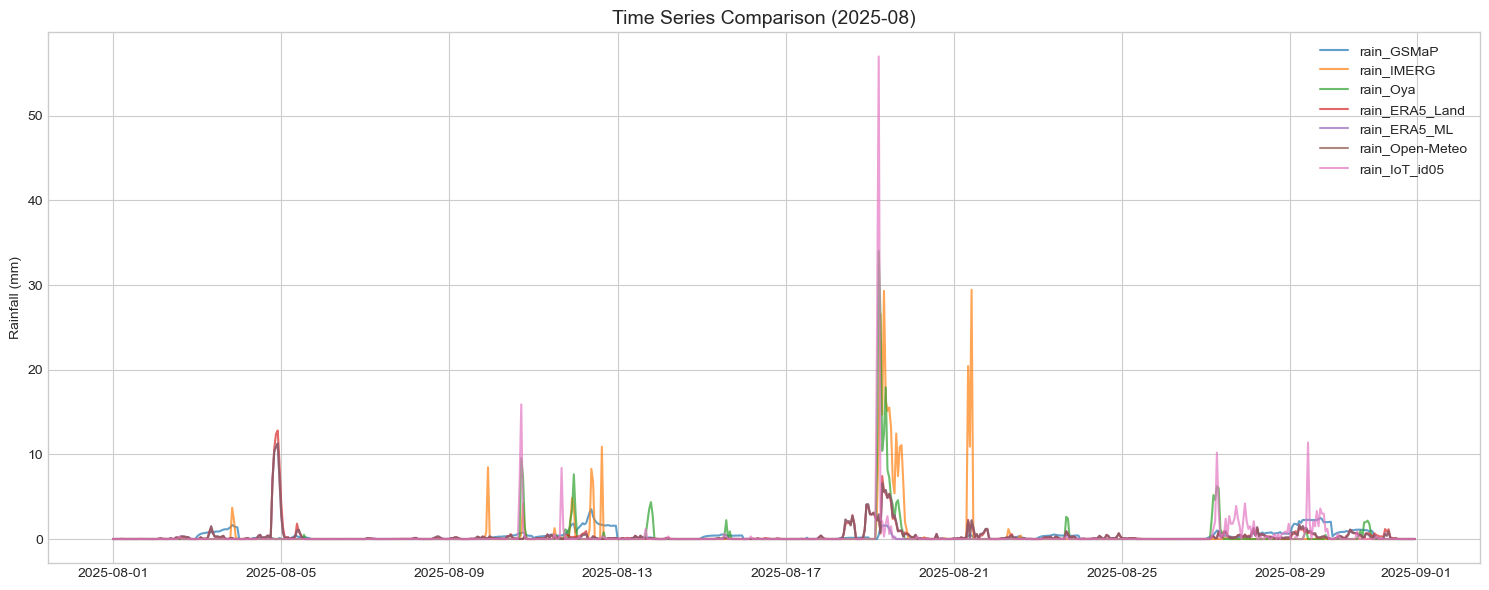

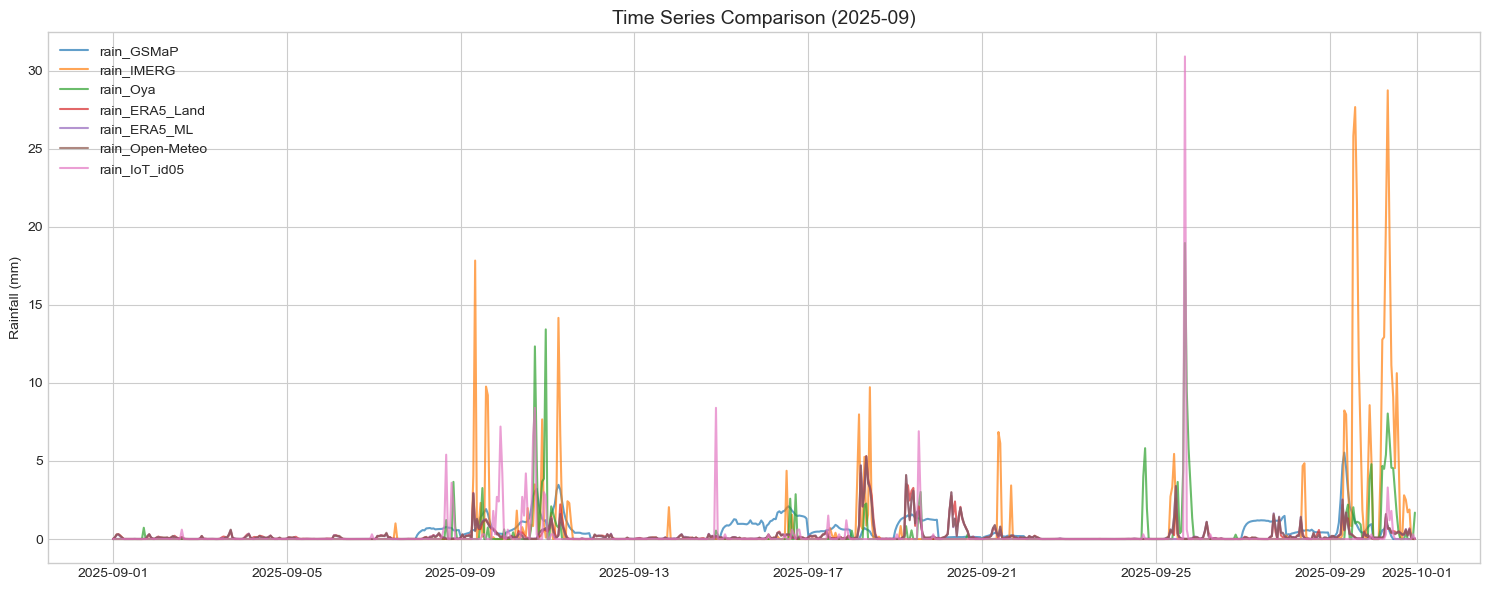

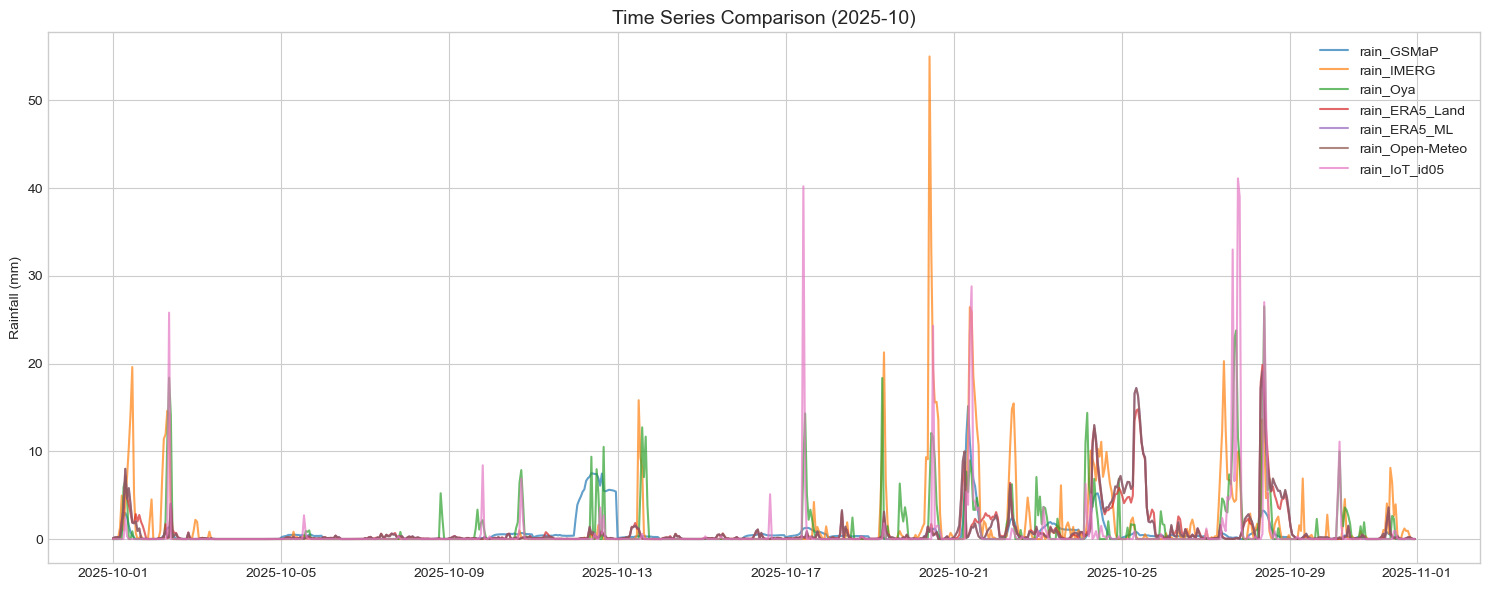

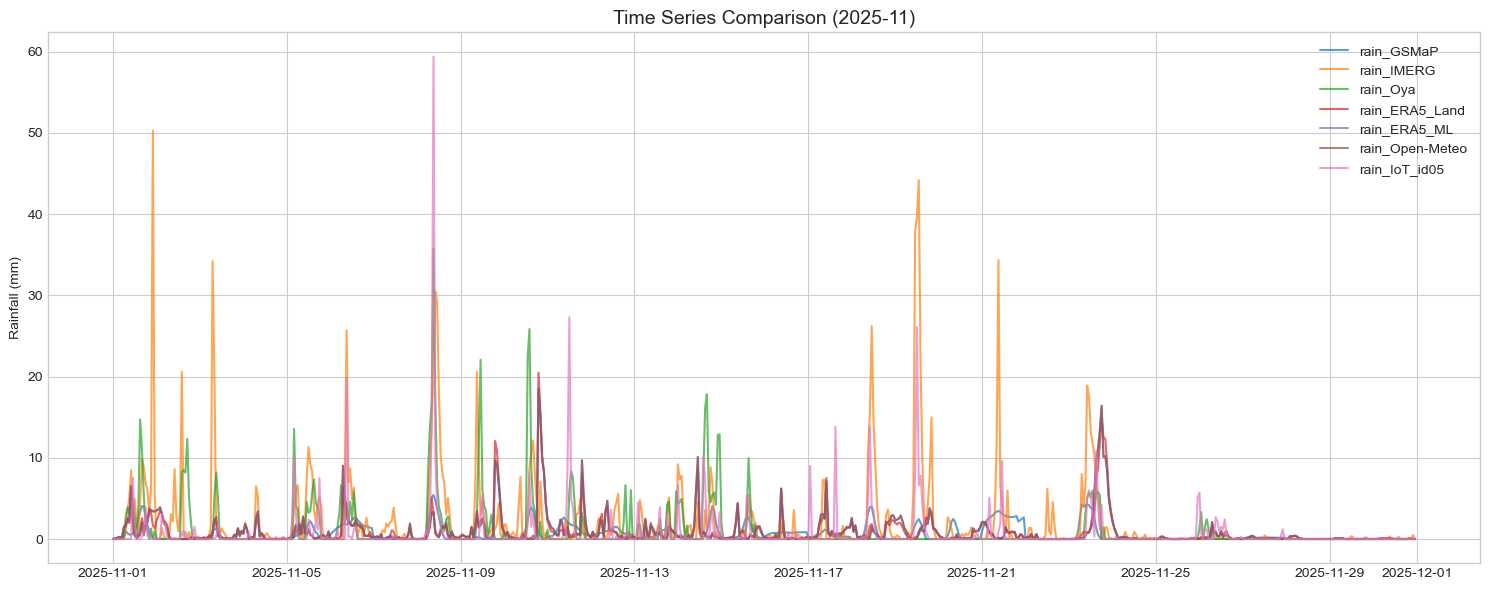

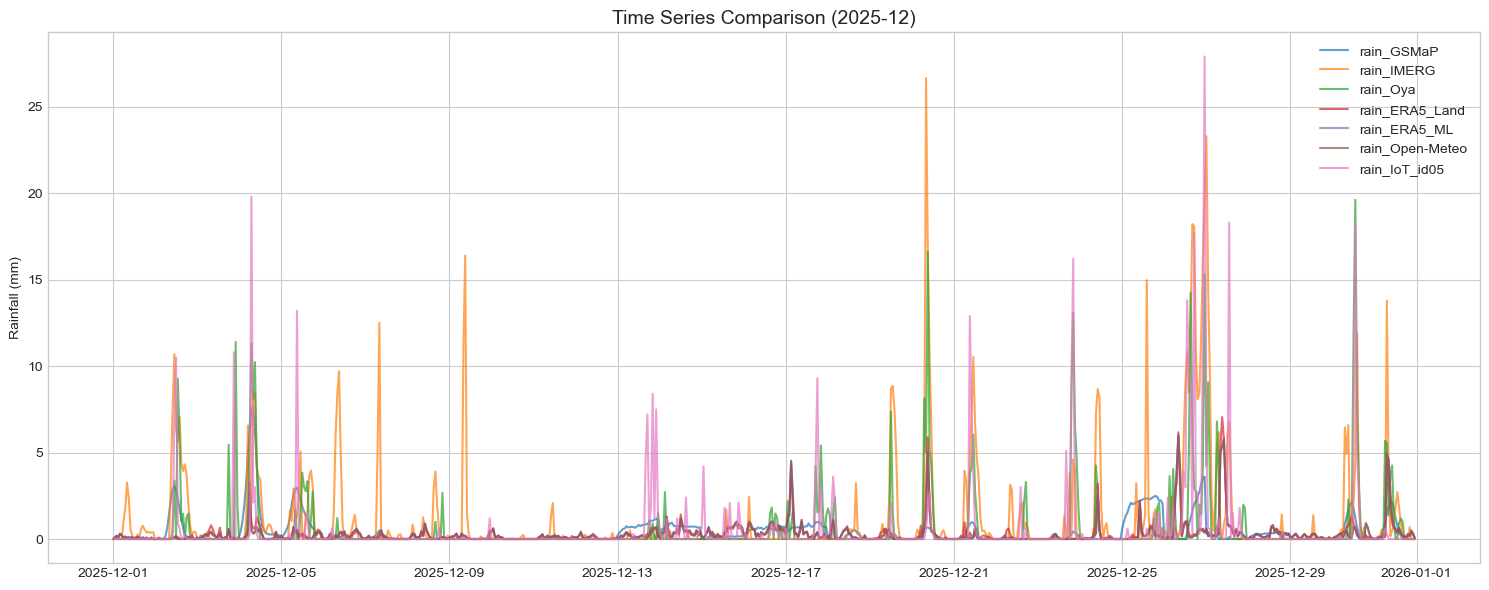

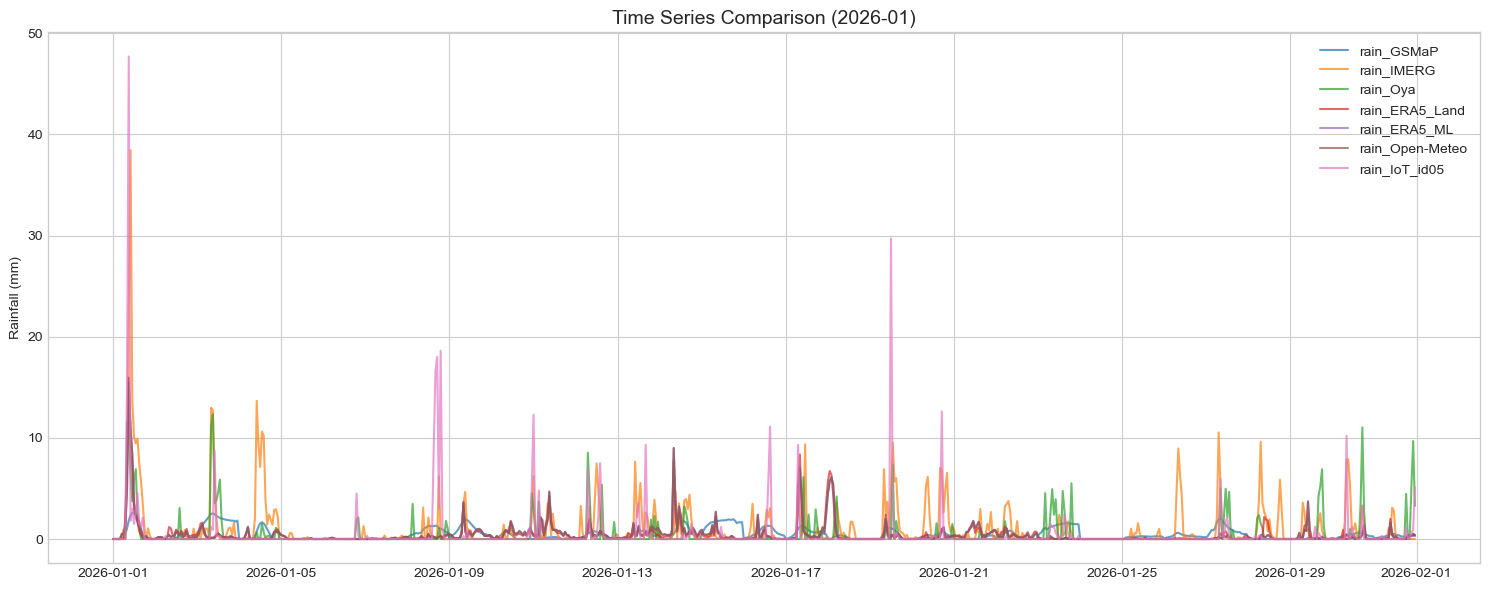

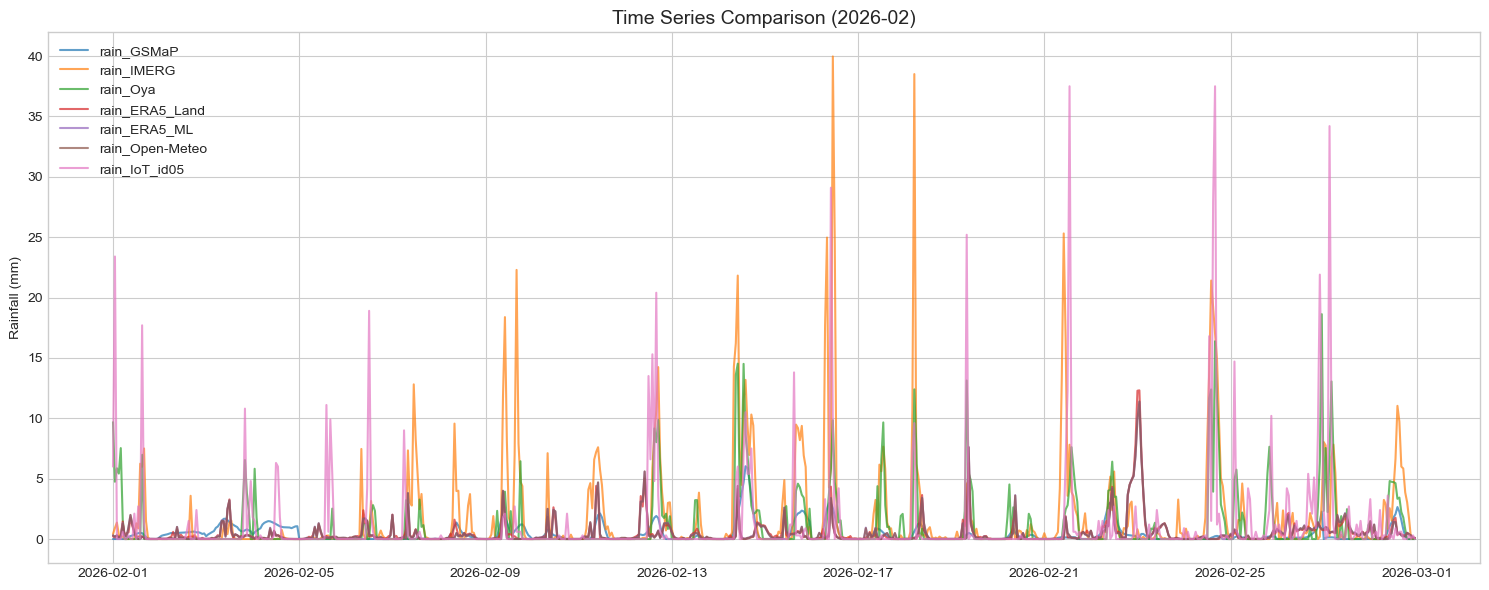

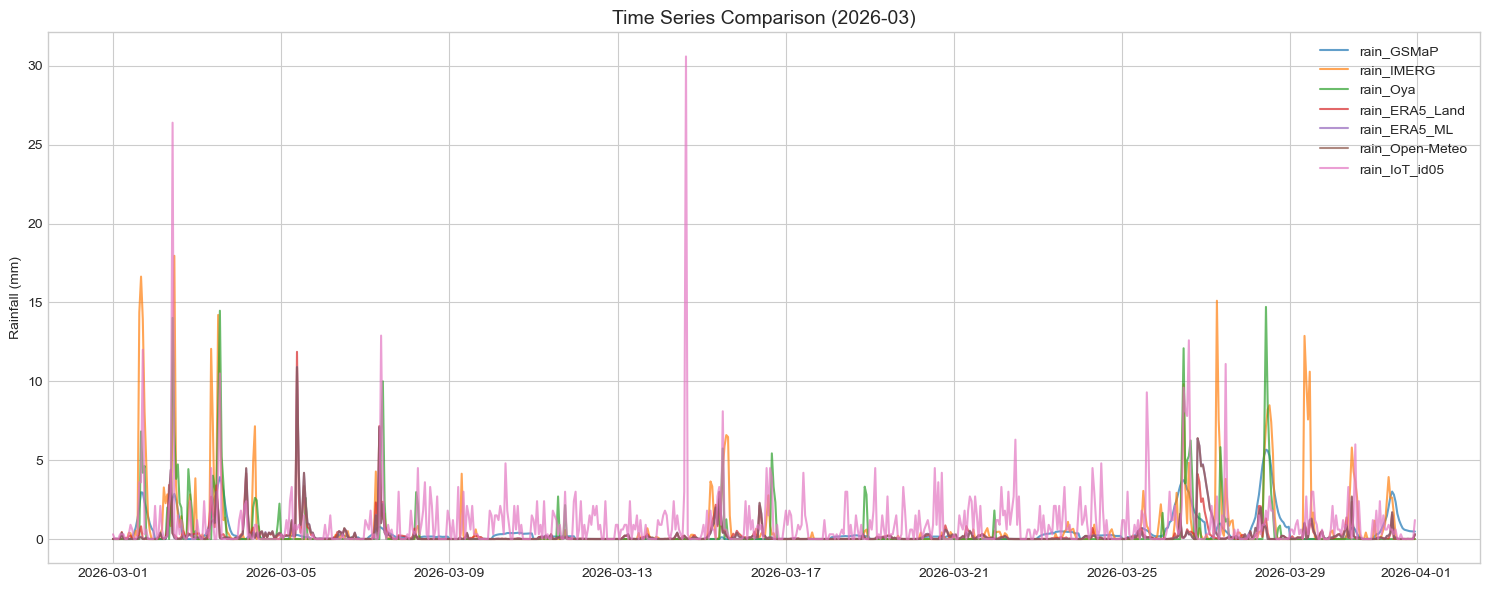

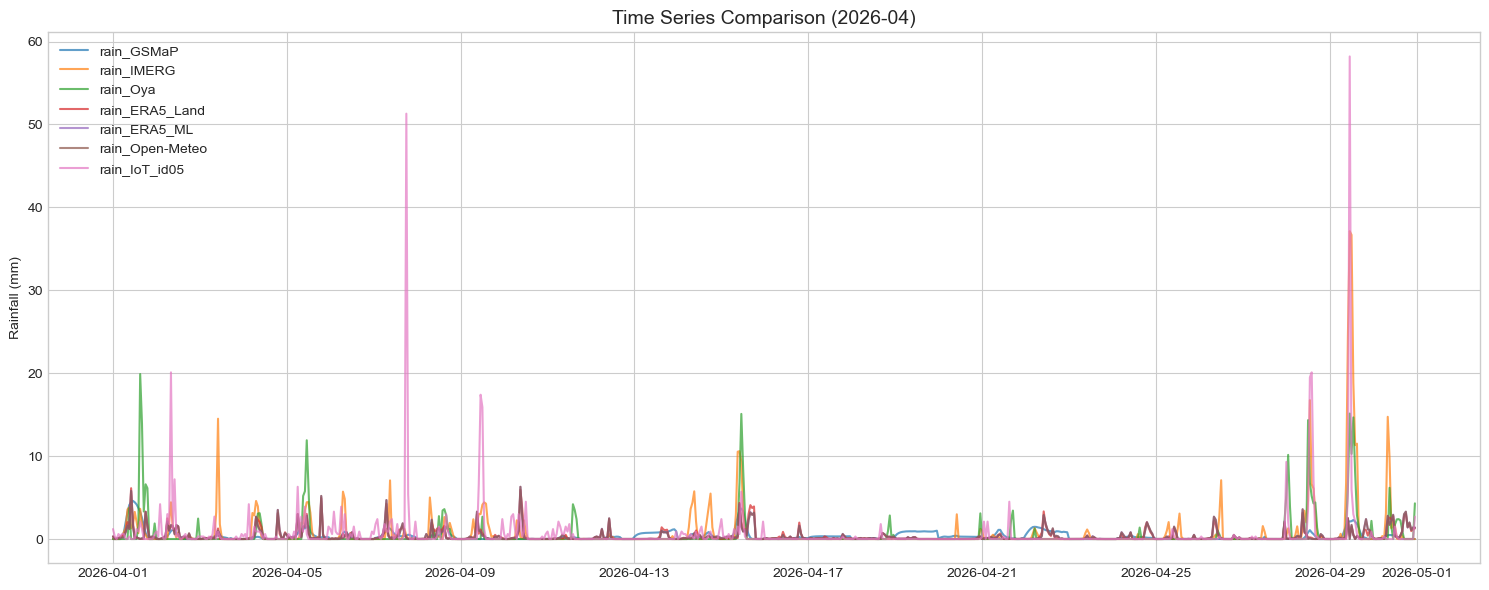

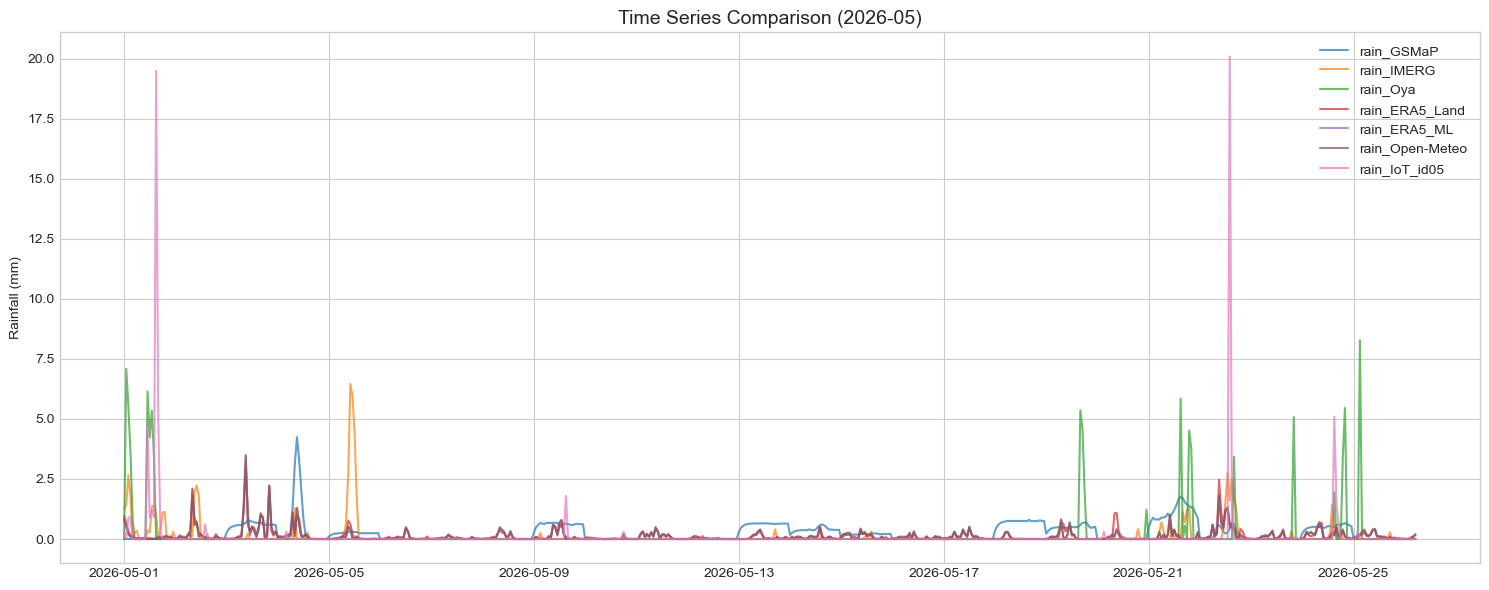

In [15]:
# Time Series Comparison (Per Bulan dan Tahun)
if not df_merged.empty:
    grouped = df_merged.groupby([df_merged.index.year, df_merged.index.month])
    
    for (year, month), df_sample in grouped:
        plt.figure(figsize=(15, 6))
        for col in rain_cols_only:
            # Plot dengan transparansi untuk membedakan
            plt.plot(df_sample.index, df_sample[col], label=col, alpha=0.7, linewidth=1.5)
            
        plt.title(f'Time Series Comparison ({year}-{month:02d})', fontsize=14)
        plt.ylabel('Rainfall (mm)')
        plt.legend()
        plt.tight_layout()
        plt.show()


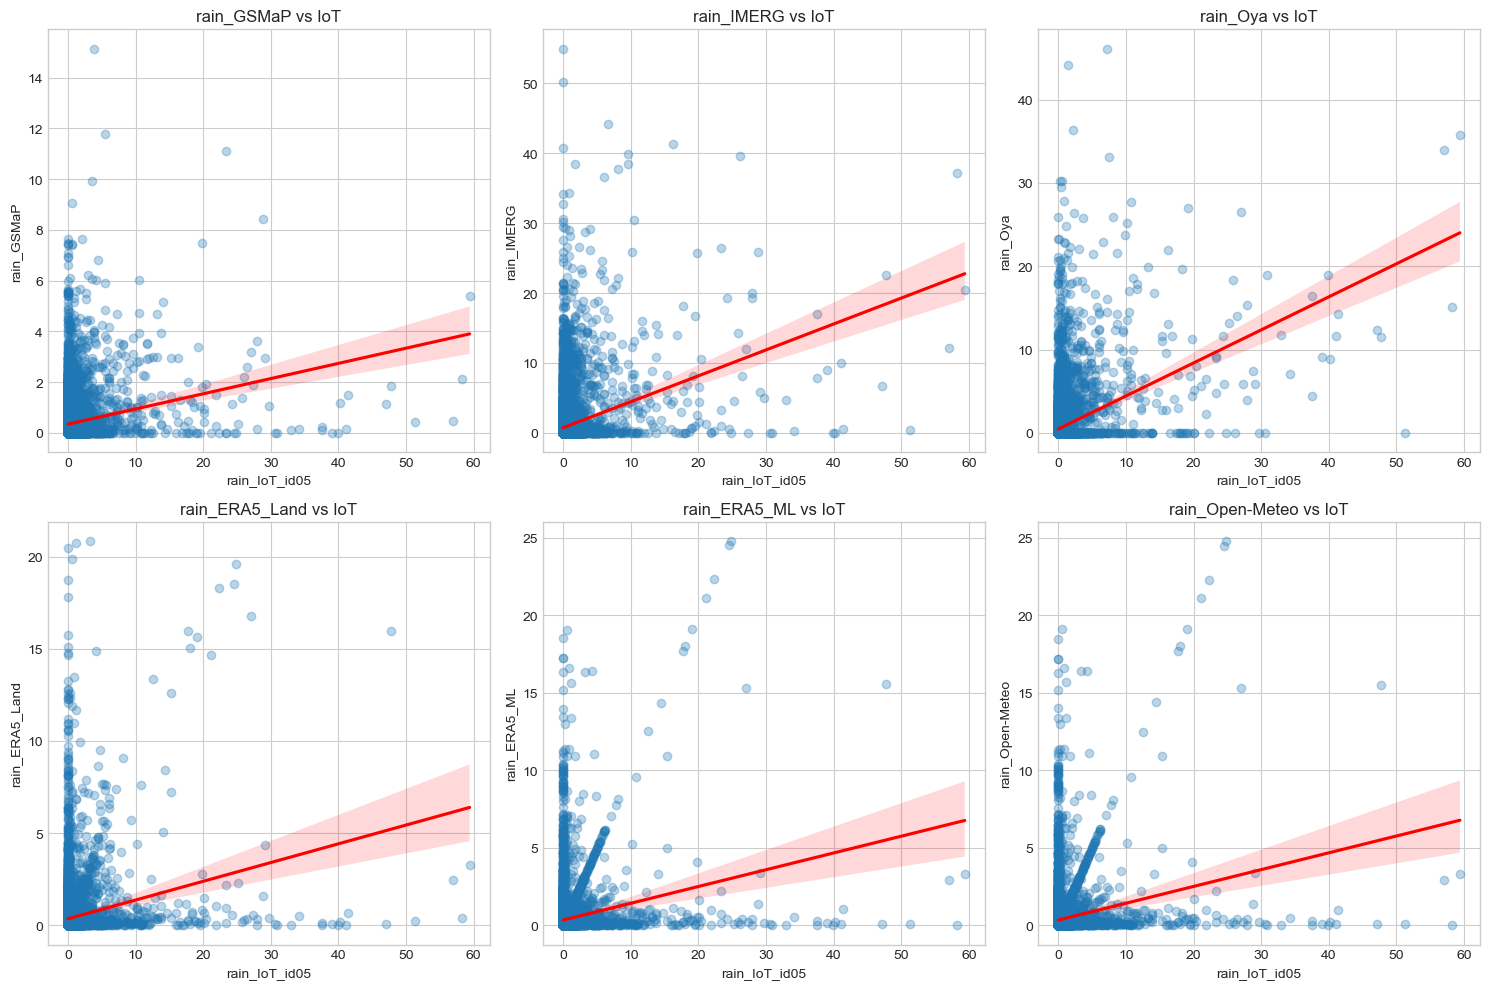

In [10]:
# Scatter Plot: Satellite/Reanalysis vs IoT
if iot_col in rain_cols_only:
    compare_cols = [c for c in rain_cols_only if c != iot_col]
    
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, col in enumerate(compare_cols):
        if i < len(axes):
            sns.regplot(data=df_merged, x=iot_col, y=col, ax=axes[i], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
            axes[i].set_title(f"{col} vs IoT")
            
    plt.tight_layout()
    plt.show()


## Phase 8 — Hydrometeorological Interpretation

### Interpretasi Hidrometeorologis

Berdasarkan matriks korelasi dan visualisasi regresi:
- **Kesesuaian dengan Stasiun Lokal (IoT)**: Stasiun lokal mewakili data "Ground Truth" titik. Korelasi antar produk berbasis grid (satelit/reanalisis) dengan titik stasiun seringkali tidak sempurna (r < 0.8) karena perbedaan skala spasial (Grid-to-Point mismatch).
- **Performa Satelit**: Produk berbasis gelombang mikro (Microwave) dan kalibrasi stasiun (GSMaP_GC / IMERG) biasanya memberikan performa terbaik dalam menangkap pola presipitasi dibandingkan produk raw.
- **Kelemahan dan Bias**:
  - Terdapat potensi **temporal lag** di mana curah hujan terekam bergeser 1-2 jam akibat perbedaan metode asimilasi atau penanganan akumulasi.
  - Curah hujan intensitas ekstrem sering "diremehkan" (underestimated) oleh reanalisis seperti ERA5 karena efek smoothing spasial dalam resolusi ~9km hingga ~30km.


## Phase 9 — Data Quality Audit
Evaluasi nilai hilang, duplikasi, dan nilai presipitasi tidak wajar (negatif).

In [11]:
audit_logs = []

missing = df_merged[rain_cols_only].isna().sum()
negatives = (df_merged[rain_cols_only] < 0).sum()
duplicates = df_merged.index.duplicated().sum()

audit_table = pd.DataFrame({
    'Missing Values': missing,
    'Negative Values': negatives
})

display(Markdown(f"- **Duplicated Timestamps in Aligned Data**: {duplicates}\n"))
display(audit_table)


- **Duplicated Timestamps in Aligned Data**: 0


,Missing Values,Negative Values
rain_GSMaP,0,0
rain_IMERG,0,0
rain_Oya,0,0
rain_ERA5_Land,0,71
rain_ERA5_ML,0,0
rain_Open-Meteo,0,0
rain_IoT_id05,0,0


## Phase 10 — Recommendations

### Recommendations for Comparison with Local Weather Station

#### 1. Data Satelit (GSMaP, IMERG, Oya)
- **Suitability**: Sangat cocok untuk analisis klimatologi dan pemantauan area yang luas (spasial).
- **Extreme Rainfall**: Cenderung mengalami bias (underestimation) pada hujan konvektif yang sangat ekstrem. Dianjurkan menggunakan GSMaP_GC (Gauge Calibrated) sebagai acuan terbaik.

#### 2. Reanalisis ERA5 (Land & ML)
- **Kekuatan**: Konsistensi temporal sangat tinggi tanpa ada data bolong. Variabel hidrodinamik lengkap.
- **Batasan**: Bukan merupakan observasi langsung. Hujan skala mikro/lokal (<9km) tidak terekam dengan akurat.
- **Keterwakilan Temporal**: Baik digunakan sebagai baseline model prediktif (Machine Learning).

#### 3. Data Open-Meteo
- **Kekuatan**: Sangat mudah diakses, sudah menggabungkan asimilasi ERA5 dan radar lokal.
- **Batasan**: Tetap mewarisi beberapa batasan reanalisis, sehingga ketidakpastian (uncertainty) tinggi pada event hujan sangat lebat.

#### 4. Stasiun IoT Lokal (id-05)
- **Saran**: Jika digunakan sebagai *Reference Truth*, bias pada sensor (tipping bucket / optik) akibat *wind-induced undercatch* perlu dikalibrasi lebih lanjut. Strategi agregasi `SUM` per jam telah sesuai, tetapi pembersihan lonjakan nilai ekstrem harus selalu dipantau.


## Phase 11 — Export Results
Menyimpan data gabungan ke dalam folder output.

In [12]:
out_dir = os.path.join(base_dir, 'Hasil_Analisis')
os.makedirs(out_dir, exist_ok=True)

parquet_path = os.path.join(out_dir, 'unified_precipitation_comparison.parquet')
csv_corr_path = os.path.join(out_dir, 'correlation_matrix.csv')

df_merged.to_parquet(parquet_path)
corr_pearson.to_csv(csv_corr_path)

display(Markdown(f"✅ **EKSPORE SELESAI**\n- Dataset tersimpan di: `{parquet_path}`\n- Matrix korelasi tersimpan di: `{csv_corr_path}`"))


✅ **EKSPORE SELESAI**
- Dataset tersimpan di: `d:/Github/Projek_Rainfall/Analisis_Meteorologi\Hasil_Analisis\unified_precipitation_comparison.parquet`
- Matrix korelasi tersimpan di: `d:/Github/Projek_Rainfall/Analisis_Meteorologi\Hasil_Analisis\correlation_matrix.csv`